In [ ]:
# Passo 1: Instalar bibliotecas
!pip install nltk
!pip install scikit-learn

In [ ]:
!pip install wordcloud
!pip install matplotlib

In [ ]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
# Passo 2: Baixar stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:






# Função para processar o texto
def process_text(text):
    # Remover pontuação e transformar em minúsculas
    text = text.lower()
    # Remover stopwords
    words = [word for word in text.split() if word.isalnum() and word not in stop_words]
    return ' '.join(words)

# Exemplo de texto
texto = """A aula hoje sobre serviço graduação ICMC. Uma aula extremamente importante para entender como fazer matrícula, entender como funcionam requerimentos, grade, trancamentos disciplinas e curso. Aprender como funcionam requisitos, períodos ideais e prioridades matrícula também foi extremamente importante, afinal, a base para conseguir progredir no curso é conseguir cursar disciplinas, e é necessário conhecimento sobre mecanismos funcionamento seção graduação para realizar essa tarefa. Nesta quarta-feira (18/03), houve visita Fernanda para falar sobre Setor Graduação ICMC. Na palestra, mostrou-se principal site para resolver possíveis problemas ao longo graduação (o Júpiter) e tiraram-se dúvidas relacionadas aos requerimentos grade horária, entre outras questões, como transferência. Esclarecedora. Nesta aula, Fernanda Maria Ortega Magro apresentou funcionamento Setor Graduação ICMC e principais sistemas acadêmicos USP. O foco chat foi Júpiter Web, plataforma onde realizam-se matrículas, consulta-se histórico escolar, verifica-se grade horária e acompanha-se requisitos curso. Mostrou-se como navegar pelo site ICMC para encontrar regulamentos, calendário acadêmico e informações sobre curso. Aprendeu-se que maioria dúvidas dia a dia já está respondida nas fontes oficiais universidade, bastando saber onde procurar. No geral, palestra foi essencial para entender como funciona vida acadêmica na USP de forma mais autônoma. Nessa aula, foram encontradas diversas informações úteis sobre curso no site ICMC. Na palestra, abordou-se sistema graduação USP. Falou-se sobre quantidade mínima créditos para cada semestre e quantidade necessária em 2 semestres para continuar "matriculado" na USP. Foram sanadas algumas dúvidas em relação matrícula disciplinas e outros assuntos. Palestra Fernanda Maria Ortega Magro teve como objetivo apresentar site Universidade São Paulo (USP) e orientar sobre como utilizá-lo forma eficiente, além de esclarecer aspectos importantes relacionados à graduação.Durante explicação, mostrou-se como navegar pelas principais seções site. Página oferece acesso rápido aos avisos importantes e links. Um pontos enfatizados foi importância conhecer Júpiter Web, onde é possível visualizar grade curricular e realizar matrícula em disciplinas. Palestrante destacou que dominar esse ambiente digital é essencial para evitar problemas acadêmicos, como perda prazos. Explicou-se que cada curso possui página própria, com detalhes sobre disciplinas, corpo docente e outros. Aconselhou-se que, em outro momento, fosse realizada exploração essas páginas para conhecer melhor oportunidades disponíveis, como iniciação científica, intercâmbios e eventos acadêmicos.Palestra também tratou questões relacionadas à graduação. Explicou-se como funciona estrutura cursos, incluindo divisão em disciplinas obrigatórias e optativas. Palestrante ressaltou que estudante deve acompanhar regularmente grade curricular e estar atento aos pré-requisitos matérias. Outro ponto relevante foi explicação sobre serviços apoio ao estudante, como bibliotecas, assistência estudantil e canais comunicação com professores e coordenação. Muitas dúvidas sobre Júpiter Web e sobre site ICMC foram sanadas."""


# Passo 3: Processar o texto
processed_text = process_text(texto)



In [ ]:
# Passo 4: Análise de TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([processed_text])

# Criar um DataFrame com os resultados
df_tfidf = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df_tfidf = df_tfidf.T.sort_values(by=0, ascending=False)

# Passo 5: Exibir as palavras mais importantes
print("Palavras mais importantes e seus valores de TF-IDF:")
print(df_tfidf)


Palavras mais importantes e seus valores de TF-IDF:
                   0
sobre       0.480996
graduação   0.262362
site        0.218635
dúvidas     0.174908
grade       0.174908
...              ...
vida        0.043727
visita      0.043727
visualizar  0.043727
web         0.043727
úteis       0.043727

[163 rows x 1 columns]


In [ ]:

# Passo 6: Criar a nuvem de palavras
# Filtrar as 50% mais importantes
top_50_percent = df_tfidf.head(len(df_tfidf) // 2)

# Criar um dicionário para a nuvem de palavras
word_freq = {word: value for word, value in zip(top_50_percent.index, top_50_percent[0])}


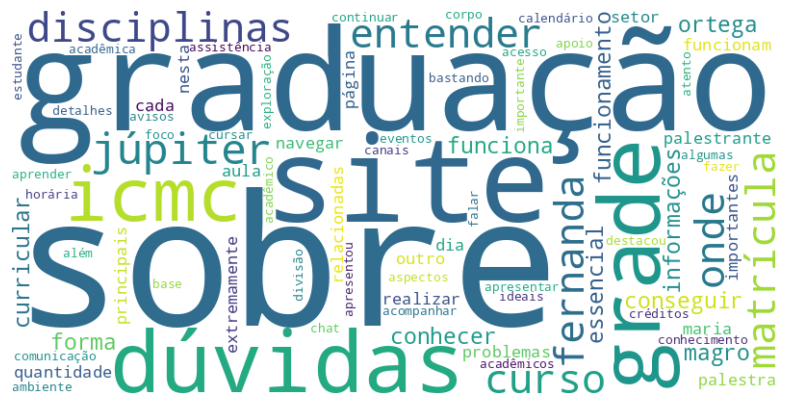

In [ ]:
# Gerar a nuvem de palavras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

# Exibir a nuvem de palavras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

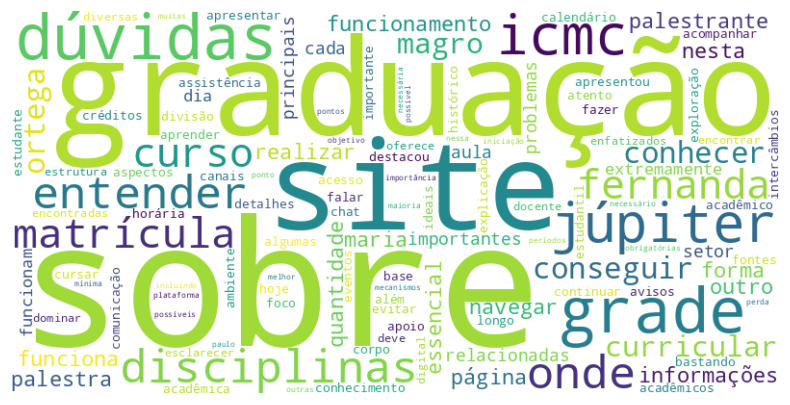

In [ ]:
# Passo 6: Criar a nuvem de palavras
# Filtrar as 75% mais importantes
top_75_percent = df_tfidf.head(int(len(df_tfidf) * 0.75))

# Criar um dicionário para a nuvem de palavras
word_freq = {word: value for word, value in zip(top_75_percent.index, top_75_percent[0])}

# Gerar a nuvem de palavras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

# Exibir a nuvem de palavras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()